Bulanık Mantık Güvenilirlik Skoru: 77.92 / 100


c:\Users\Zeki Kurt\Desktop\piton-nlp-fuzzy-case\venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


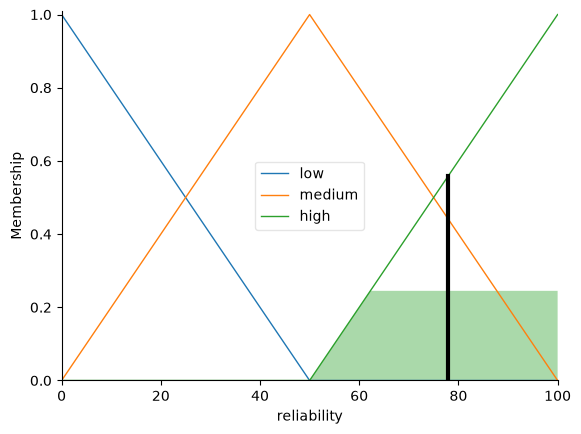

In [ ]:
import pandas as pd
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt


df_raw = pd.read_csv('../data/raw/dataset.csv', low_memory=False)
df = pd.read_csv('../data/processed/nlp_processed_reviews.csv')


df_raw['reviews.date'] = pd.to_datetime(df_raw['reviews.date'], errors='coerce')
max_date = df_raw['reviews.date'].max() 
df_raw['review_age_days'] = (max_date - df_raw['reviews.date']).dt.days

df['review_age'] = df_raw['review_age_days'].fillna(365) 
df['review_length'] = df['text'].apply(lambda x: len(str(x).split()))

# ==========================================
# 2. BULANIK MANTIK SİSTEMİ (FUZZY INFERENCE SYSTEM)
# ==========================================


rating = ctrl.Antecedent(np.arange(1, 6, 1), 'rating')         
length = ctrl.Antecedent(np.arange(0, 151, 1), 'length')      
age = ctrl.Antecedent(np.arange(0, 2000, 1), 'age')            
reliability = ctrl.Consequent(np.arange(0, 101, 1), 'reliability') 

rating.automf(3, names=['low', 'medium', 'high'])

length['short'] = fuzz.zmf(length.universe, 0, 20)
length['medium'] = fuzz.trapmf(length.universe, [10, 30, 60, 100])
length['long'] = fuzz.smf(length.universe, 50, 150)

age['new'] = fuzz.zmf(age.universe, 0, 180)           
age['moderate'] = fuzz.trapmf(age.universe, [90, 180, 730, 1095]) 
age['old'] = fuzz.smf(age.universe, 730, 2000)          

reliability.automf(3, names=['low', 'medium', 'high'])

# Kurallar (Rule Base)
rule1 = ctrl.Rule(length['long'] & age['new'], reliability['high'])
rule2 = ctrl.Rule(length['short'], reliability['low'])
rule3 = ctrl.Rule(rating['medium'] & length['medium'], reliability['medium'])
rule4 = ctrl.Rule(length['long'] & age['old'], reliability['medium'])
rule5 = ctrl.Rule(rating['low'] & length['long'], reliability['high']) 

# Kontrol Sistemi
reliability_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5])
reliability_sim = ctrl.ControlSystemSimulation(reliability_ctrl)

# ==========================================
# 3. Örnek Bir Yorum Üzerinde Test Etme
# ==========================================
# Örnek: Puanı 1, Uzunluğu 85 kelime (Uzun), Yaşı 30 gün (Yeni) olan bir yorum
reliability_sim.input['rating'] = 1
reliability_sim.input['length'] = 85
reliability_sim.input['age'] = 30

reliability_sim.compute()
print(f"Bulanık Mantık Güvenilirlik Skoru: {reliability_sim.output['reliability']:.2f} / 100")

# Çıktı görselleştirmesi
reliability.view(sim=reliability_sim)
plt.show()

Güvenilirlik Skorunun Model Tahminini Ağırlıklandırması:
Bulanık çıkarım sistemiyle üretilen (0-100) güvenilirlik skoru, makine öğrenmesi modelimizin çıktı olasılıklarını (predict_proba) kalibre etmek için kullanılabilir. Örneğin, model bir yoruma %80 ihtimalle "Olumlu" derse; ancak bulanık mantık bu yorumun çok kısa ve eski olmasından ötürü güvenilirlik skorunu 20/100 ("Low") olarak belirlerse, nihai ağırlıklandırılmış olasılık (0.80 * 0.20 = 0.16) olarak düşürülür. Böylece, API aracılığıyla "Haftanın Öne Çıkan Şikayetleri" raporlanırken yalnızca NLP tahminleri yüksek olanlar değil, aynı zamanda Bulanık Mantık skoruna göre gerçekten emek verilerek yazılmış, yeni tarihli güvenilir yorumlar filtrelenebilir.